# 3. Exploratory Data Analysis


## 3.0 Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


sns.set(style="whitegrid")

In [ ]:
neiss_2024_analysis = pd.read_csv('../clean_data/neiss_2024_analysis.csv')

neiss_2024_analysis.head(2).T


,0,1
cpsc_case_number,240108461,240108462
treatment_date,2024-01-01,2024-01-01
age_year,16.0,56.0
sex,male,female
race,unknown,white
hispanic,yes,no
body_part,shoulder,finger
diagnosis,"strain, sprain",laceration
location,place of recreation or sports,home
fire_involvement,no_fire_or_not_recorded,no_fire_or_not_recorded


##3.1 Defining Numeric and Categorical Columns

In [ ]:
numeric_cols = ['age_year']

categorical_cols =['sex', 'race', 'hispanic', 'body_part',
       'diagnosis', 'location', 'fire_involvement', 'alcohol',
       'drug', 'disposition']

### 3.1.1 Summary Statistics for The Numeric Columns

Age is the only continuous variable in the dataset and is summarized using standard descriptive statistics.

In [ ]:
neiss_2024_analysis['age_year'].describe()

,age_year
count,361285.000000
mean,34.695458
std,28.364625
min,0.083333
25%,10.000000
50%,26.000000
75%,60.000000
max,110.000000


### 3.1.2 Frequency Count Categorical Distribution

Categorical variables are examined using frequency counts to assess distribution, dominance of categories, and sparsity in rare outcomes.

In [ ]:
for col in categorical_cols:
    print(f"Unique values in {col}:")
    print(neiss_2024_analysis[col].value_counts())
    print("\n")

Unique values in sex:
sex
male      197872
female    163413
Name: count, dtype: int64


Unique values in race:
race
white                               208613
black/african american               67920
unknown                              58397
other                                15264
asian                                 8908
american indian/alaska native         1503
native hawaiian/pacific islander       680
Name: count, dtype: int64


Unique values in hispanic:
hispanic
no         258743
yes         51582
unknown     50960
Name: count, dtype: int64


Unique values in body_part:
body_part
head              68716
face              31146
lower trunk       27786
finger            27142
upper trunk       21237
knee              18313
ankle             18156
shoulder          14239
hand              13183
foot              12696
lower leg         12679
lower arm         11522
wrist             11406
all parts body     9780
unknown            9540
elbow              8333
mouth          

## 3.2 Univariate Analysis

### 3.2.1 Distribution of Datetime
The temporal distribution of injury cases is examined to identify potential seasonality patterns and short-term fluctuations within 2024.

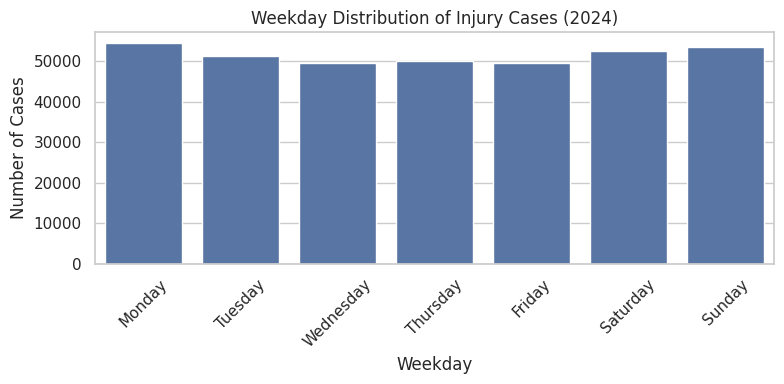

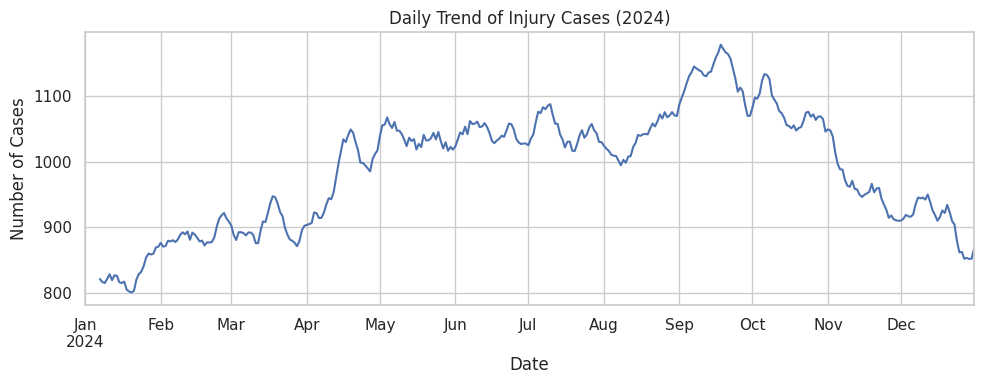

In [ ]:
neiss_2024_analysis['treatment_date'] = pd.to_datetime(
    neiss_2024_analysis['treatment_date'], errors='coerce')

# --- Weekday Distribution ---
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
                 'Friday', 'Saturday', 'Sunday']

weekday_counts = (
    neiss_2024_analysis['treatment_date']
    .dt.day_name()
    .value_counts()
    .reindex(weekday_order))

plt.figure(figsize=(8, 4))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values)
plt.title("Weekday Distribution of Injury Cases (2024)")
plt.xticks(rotation=45)
plt.xlabel("Weekday")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.show()


# --- Time Trend (Daily Level) ---
daily_counts = neiss_2024_analysis.groupby(neiss_2024_analysis['treatment_date']).size().sort_index()

plt.figure(figsize=(10, 4))
daily_counts.rolling(7).mean().plot()
plt.title("Daily Trend of Injury Cases (2024)")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.show()

- Weekend cases are slightly higher than weekdays, but the difference is small, suggesting injury risk is relatively consistent throughout the week.

- Injury cases increase from April, peak around September, and then decline toward the end of the year, showing a clear seasonal pattern.

### 3.2.2 Distribution of Numerical Variables

Visualizing the distribution of age_year:


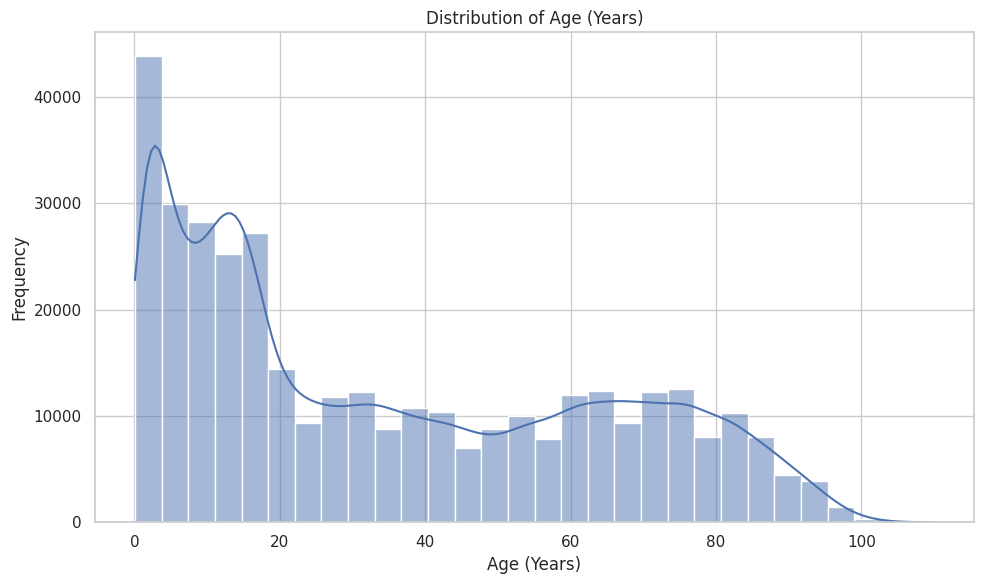

In [ ]:
print("Visualizing the distribution of age_year:")

plt.figure(figsize=(10, 6))
sns.histplot(neiss_2024_analysis['age_year'], bins=30, kde=True)
plt.title('Distribution of Age (Years)')
plt.xlabel('Age (Years)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

- The age distribution shows a right-skewed pattern, with most patients concentrated at younger ages and a long tail extending into older age groups.

### 3.2.3 Distribution of Categorical Variables

Categorical variables are examined using frequency counts to assess category dominance and distributional imbalance.

Visualizing distributions of categorical features:


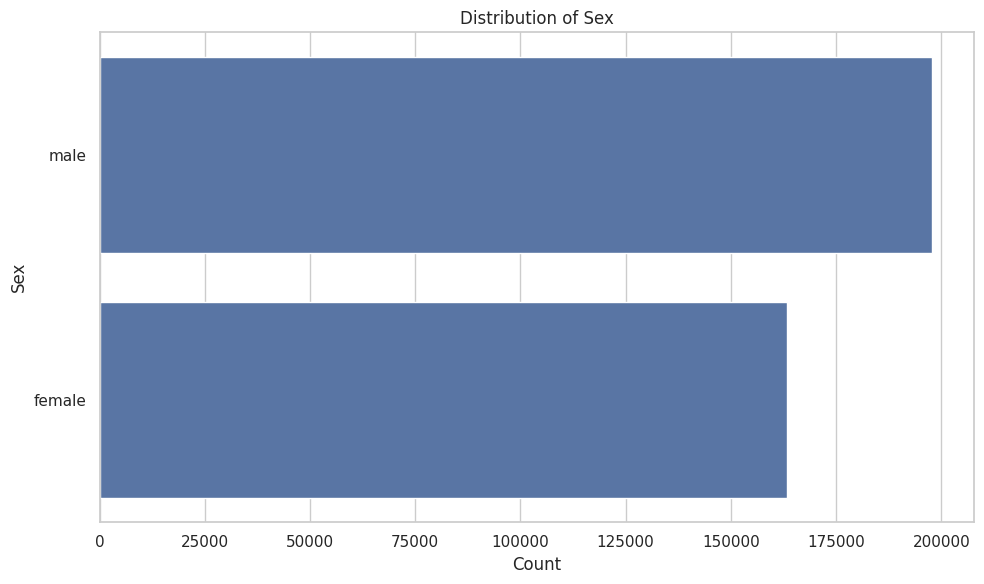

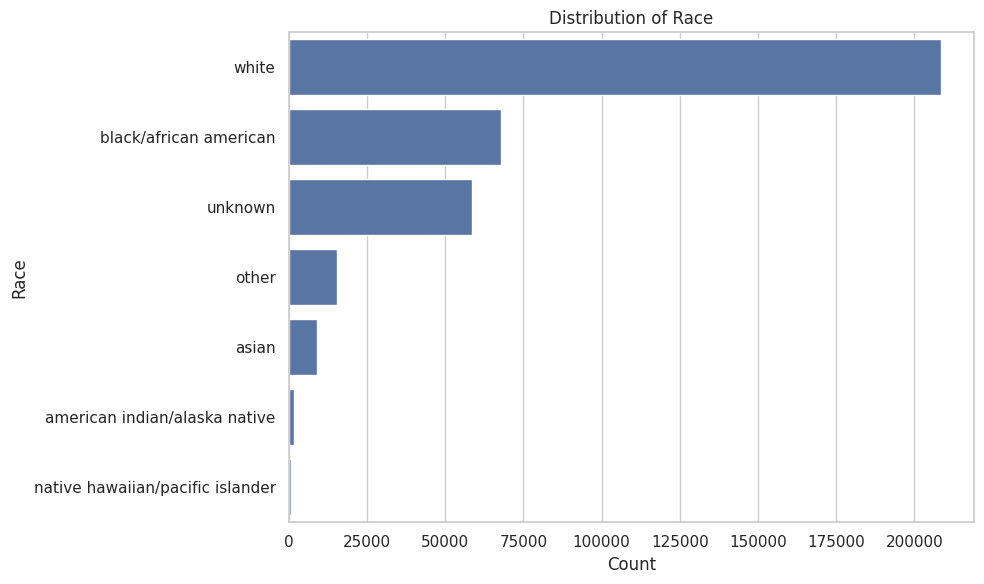

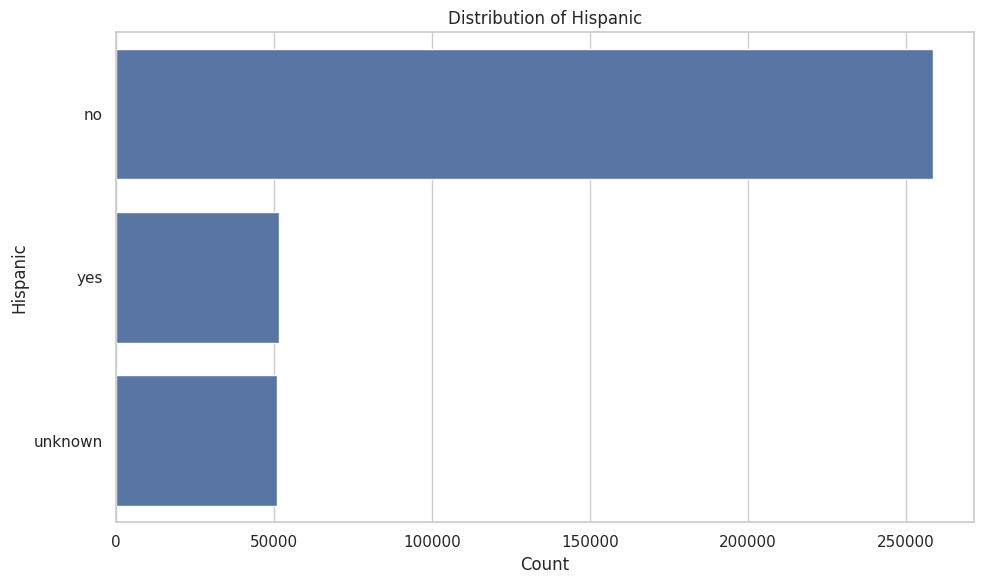

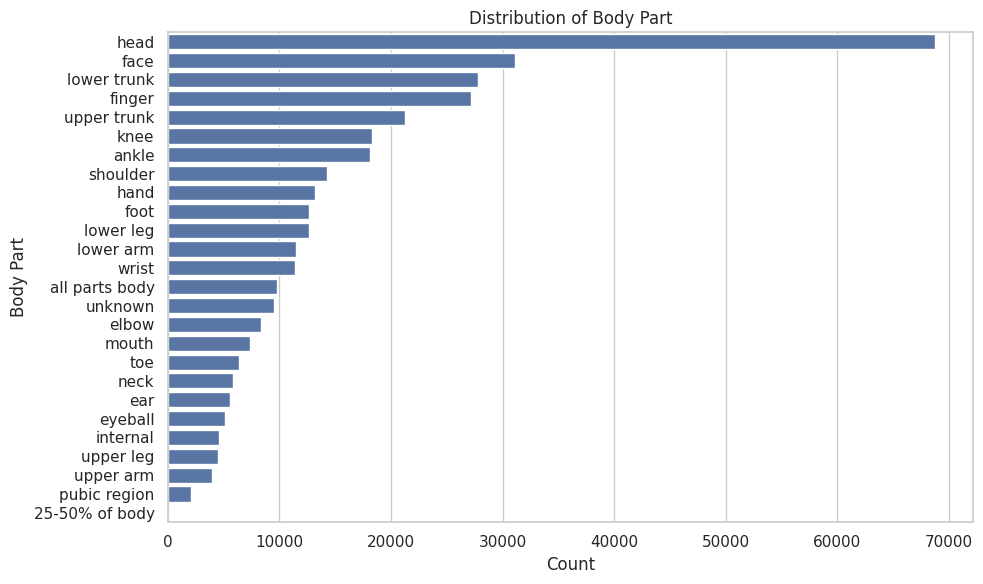

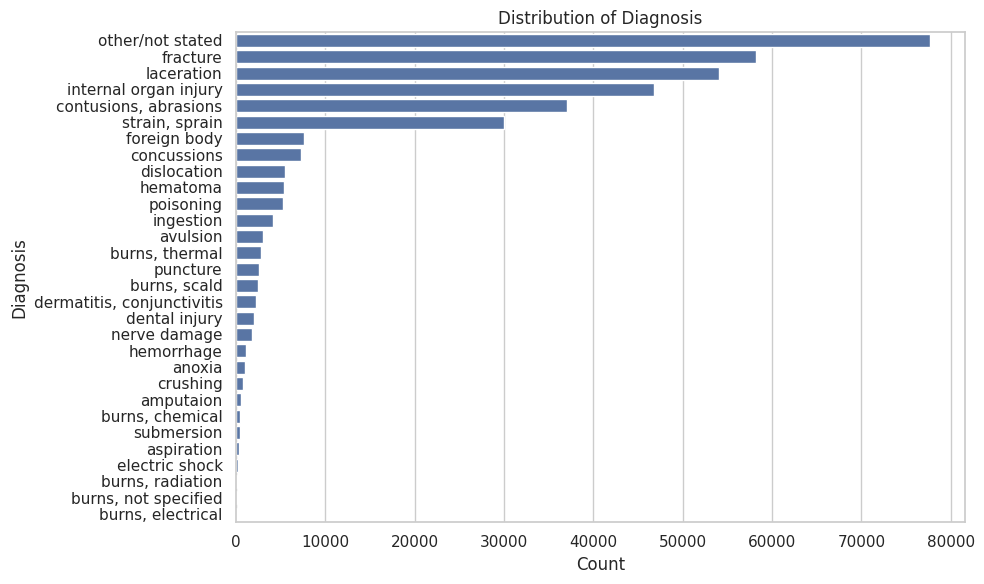

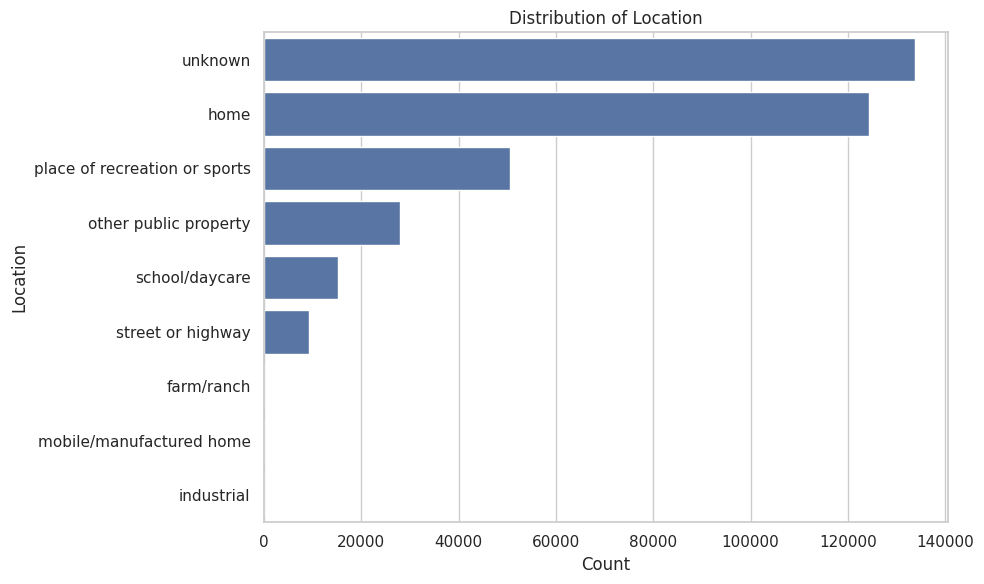

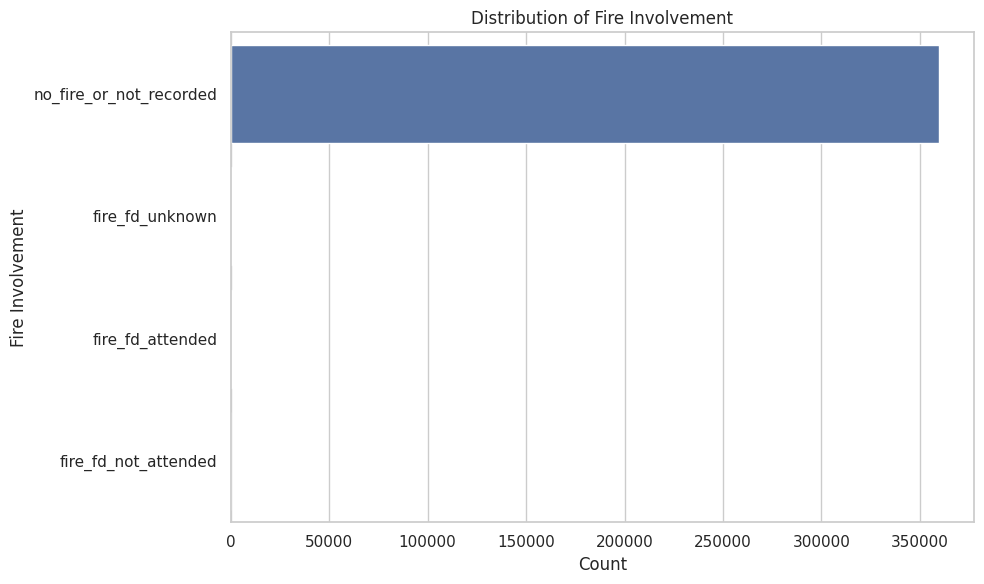

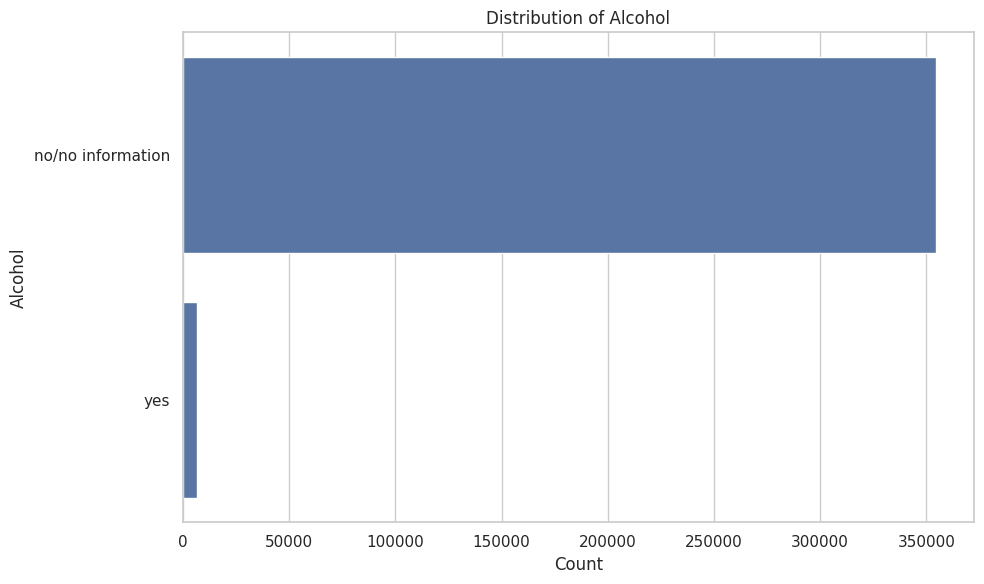

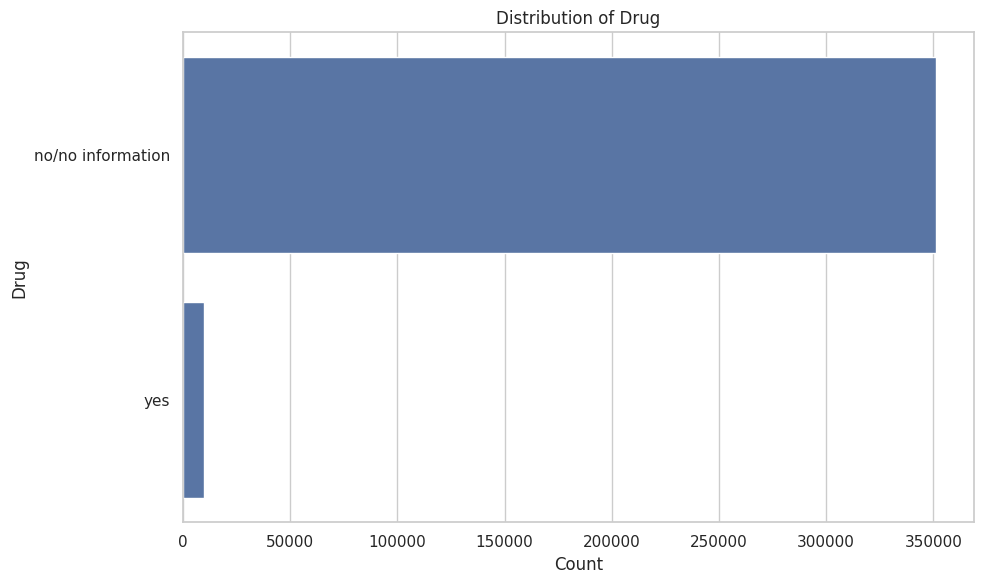

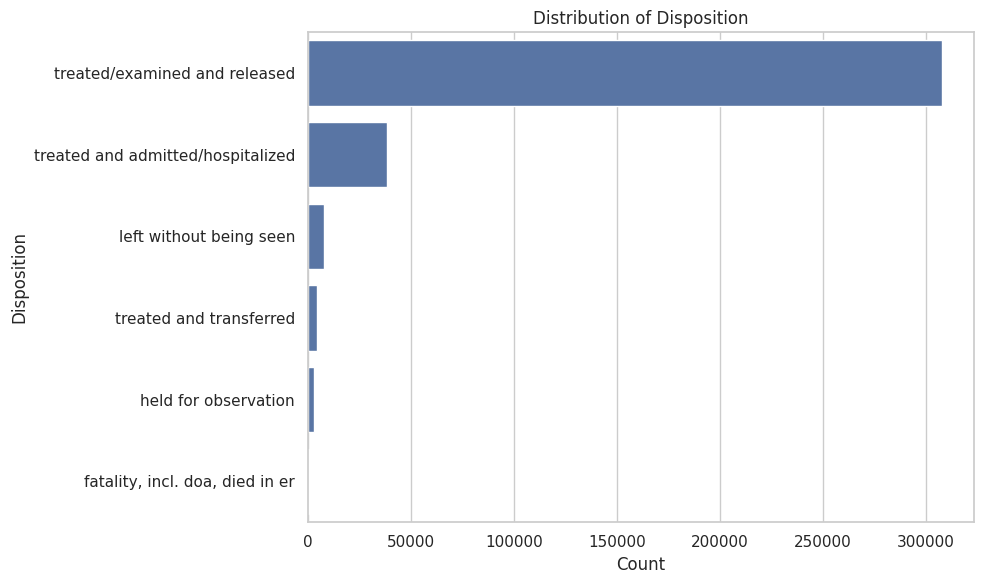

In [ ]:
print("Visualizing distributions of categorical features:")

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=neiss_2024_analysis, y=col, order=neiss_2024_analysis[col].value_counts().index)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel('Count')
    plt.ylabel(col.replace("_", " ").title())
    plt.tight_layout()
    plt.show()
    plt.close()

The Key Observations of Categorical Variables:
- Sex: The dataset shows a slight male predominance.
- Race: White patients represent the largest proportion, followed by Black/African American individuals.
- Hispanic Ethnicity: Most patients are non-Hispanic.
- Body Part: Injuries most commonly involve the head.
- Diagnosis: The largest category is other/not stated; fractures and lacerations are the most common specified diagnoses.
- Location: The most common location is unknown, followed by incidents occurring at home.
- Fire Involvement: Most cases report no fire involvement.
- Alcohol and drug-related cases constitute a small proportion of total injuries.
- Disposition: The majority of patients are treated and released without hospitalization.


## 3.3 Bivariate Analysis

### 3.3.1 Admission Rates by Patient and Injury Factors

We examined the difference in admission rates across categories, leaving out ID and sampling-related variables.

The range of admission rates was used as a descriptive measure of variability, rather than a formal statistical test of association.

In [ ]:
target = 'admitted'

exclude_cols = ['cpsc_case_number', 'disposition','weight', 'psu', 'stratum']

categorical_cols = [
    col for col in neiss_2024_analysis.columns
    if col not in exclude_cols + [target]
    and neiss_2024_analysis[col].dtype.name in ['object', 'category']
]

results = []

for col in categorical_cols:
    admission_rate = neiss_2024_analysis.groupby(col, observed=True)['admitted'].mean()
    rate_range = admission_rate.max() - admission_rate.min()
    results.append({'variable': col,'range': rate_range})

importance_df = pd.DataFrame(results)
importance_df.sort_values('range', ascending=False)

,variable,range
9,narrative_1,1.000000
3,body_part,0.890783
4,diagnosis,0.422434
6,fire_involvement,0.333760
11,age_group,0.267774
5,location,0.229432
8,drug,0.169911
7,alcohol,0.129125
1,race,0.067517
2,hispanic,0.053022


- We focused on variables with the largest differences in admission rates—body_part (89.1%), diagnosis (42.2%), fire_involvement (33.4%), age_group (26.8%), and location (22.9%).

- Other variables showed less than a 20% difference and were considered to have minimal impact on hospital admission.

#### 3.3.1.1 Body Part × Admission（Top 10）

In [ ]:
pd.crosstab(
    neiss_2024_analysis['body_part'],
    neiss_2024_analysis['admitted'],
    normalize='index'
).sort_values( 1, ascending=False).head(10)

admitted,0,1
body_part,,
25-50% of body,0.095238,0.904762
upper leg,0.631380,0.368620
unknown,0.659748,0.340252
lower trunk,0.744332,0.255668
all parts body,0.765440,0.234560
upper trunk,0.777793,0.222207
upper arm,0.793962,0.206038
neck,0.837461,0.162539
internal,0.849804,0.150196


####3.3.1.2 Diagnosis × Admission (Top 10)

In [ ]:
pd.crosstab(
    neiss_2024_analysis['diagnosis'],
    neiss_2024_analysis['admitted'],
    normalize='index'
).sort_values( 1, ascending=False).head(10)

admitted,0,1
diagnosis,,
submersion,0.577566,0.422434
amputaion,0.731588,0.268412
fracture,0.740766,0.259234
"burns, thermal",0.792129,0.207871
anoxia,0.798658,0.201342
poisoning,0.815046,0.184954
"burns, electrical",0.818182,0.181818
aspiration,0.827485,0.172515
"burns, not specified",0.842697,0.157303


####3.3.1.3 Fire involvement × Admission

In [ ]:
pd.crosstab(
    neiss_2024_analysis['fire_involvement'],
    neiss_2024_analysis['admitted'],
    normalize='index'
).sort_values( 1, ascending=False)

admitted,0,1
fire_involvement,,
fire_fd_attended,0.550584,0.449416
fire_fd_unknown,0.658898,0.341102
fire_fd_not_attended,0.764045,0.235955
no_fire_or_not_recorded,0.884344,0.115656


####3.3.1.4 Age × Admission

In [ ]:
pd.crosstab(
    neiss_2024_analysis['age_group'],
    neiss_2024_analysis['admitted'],
    normalize='index'
).sort_values( 1, ascending=False)

admitted,0,1
age_group,,
elderly (65+),0.692778,0.307222
older adult (50-64),0.838670,0.161330
mid adult (35-49),0.910247,0.089753
infant (<1),0.944253,0.055747
young adult (18-34),0.945174,0.054826
child (5-12),0.958136,0.041864
toddler (1-4),0.958251,0.041749
adolescent (13-17),0.960552,0.039448


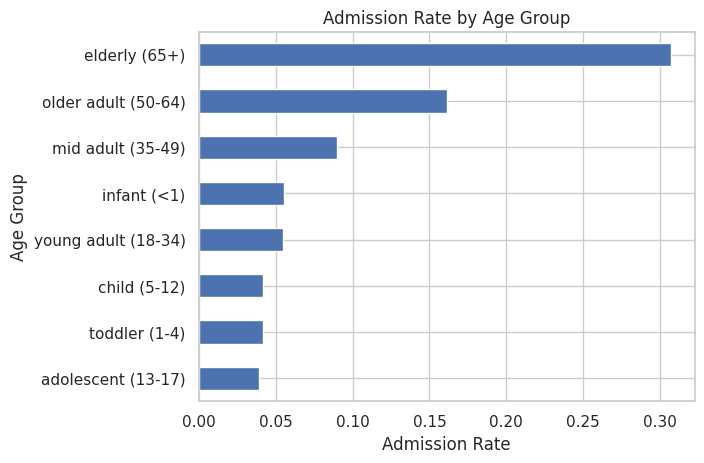

In [ ]:
age_admission = (
    neiss_2024_analysis
    .groupby('age_group')['admitted']
    .mean()
    .sort_values()
)

age_admission.plot(kind='barh')
plt.title("Admission Rate by Age Group")
plt.xlabel("Admission Rate")
plt.ylabel("Age Group")
plt.show()

#### 3.3.1.5 Location × Admission

In [ ]:
pd.crosstab(
    neiss_2024_analysis['location'],
    neiss_2024_analysis['admitted'],
    normalize='index'
).sort_values( 1, ascending=False)


admitted,0,1
location,,
mobile/manufactured home,0.739726,0.260274
other public property,0.817747,0.182253
farm/ranch,0.826087,0.173913
street or highway,0.830541,0.169459
home,0.842416,0.157584
unknown,0.904002,0.095998
place of recreation or sports,0.948432,0.051568
industrial,0.956522,0.043478
school/daycare,0.969158,0.030842


Admission Patterns Summary (Bivariate Insight)

- Relatively high hospital admission rates were observed for injuries involving large portions of the body, submersion incidents, fire department–attended events, and older adults (65+).

- Lower admission rates were observed in recreational, industrial, and school/daycare settings, as well as in non-fire incidents and among younger individuals.

These patterns highlight which variables are likely to be most informative for subsequent multivariate analyses.

## 3.4 Multivariate Descriptive Analysis

### 3.4.1 Does the association between fire involvement and admission vary across age groups?

In [ ]:
age_fire_table = (
    neiss_2024_analysis
    .groupby(['age_group', 'fire_involvement'], observed=True)
    .agg(admission_rate=('admitted', 'mean'),
        sample_size=('admitted', 'size'))
    .reset_index()
)

age_fire_table['admission_rate'] = age_fire_table['admission_rate'] * 100

age_fire_table.sort_values('age_group', ascending=False).head()

,age_group,fire_involvement,admission_rate,sample_size
31,young adult (18-34),no_fire_or_not_recorded,5.317077,53394
30,young adult (18-34),fire_fd_unknown,25.984252,254
29,young adult (18-34),fire_fd_not_attended,16.304348,92
28,young adult (18-34),fire_fd_attended,36.470588,85
27,toddler (1-4),no_fire_or_not_recorded,4.150160,42408


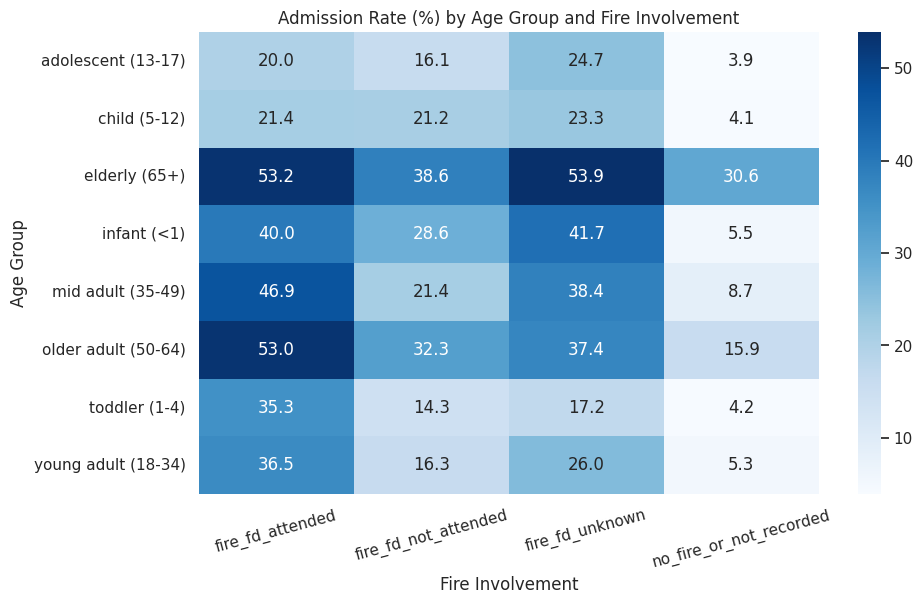

In [ ]:
age_fire_heatmap = (
    age_fire_table
    .pivot(index='age_group',
           columns='fire_involvement',
           values='admission_rate')
)

plt.figure(figsize=(10,6))
sns.heatmap(
    age_fire_heatmap,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Admission Rate (%) by Age Group and Fire Involvement")
plt.ylabel("Age Group")
plt.xlabel("Fire Involvement")
plt.xticks(rotation= 15)
plt.show()



- Admission rates are substantially higher in fire-related incidents compared to non-fire cases across all age groups.
- The effect is particularly pronounced among elderly patients (65+), whose admission rates exceed 30% across all fire involvement categories and surpass 50% in several of them.

### 3.4.2 Does admission risk differ by location across age groups?

In [ ]:
age_location_table = (
    neiss_2024_analysis
    .groupby(['age_group', 'location'], observed=True)
    .agg(
        admission_rate=('admitted', 'mean'),
        sample_size=('admitted', 'size')
    )
    .reset_index()
)

age_location_table['admission_rate'] *= 100


age_location_table.sort_values('age_group', ascending=False).head(10)

,age_group,location,admission_rate,sample_size
69,young adult (18-34),unknown,5.012065,25279
68,young adult (18-34),street or highway,12.870662,3170
67,young adult (18-34),school/daycare,4.651163,301
66,young adult (18-34),place of recreation or sports,4.219562,8271
65,young adult (18-34),other public property,8.463612,3710
64,young adult (18-34),mobile/manufactured home,0.000000,7
63,young adult (18-34),industrial,0.000000,14
62,young adult (18-34),home,4.573661,13053
61,young adult (18-34),farm/ranch,10.000000,20
57,toddler (1-4),place of recreation or sports,4.435831,2322


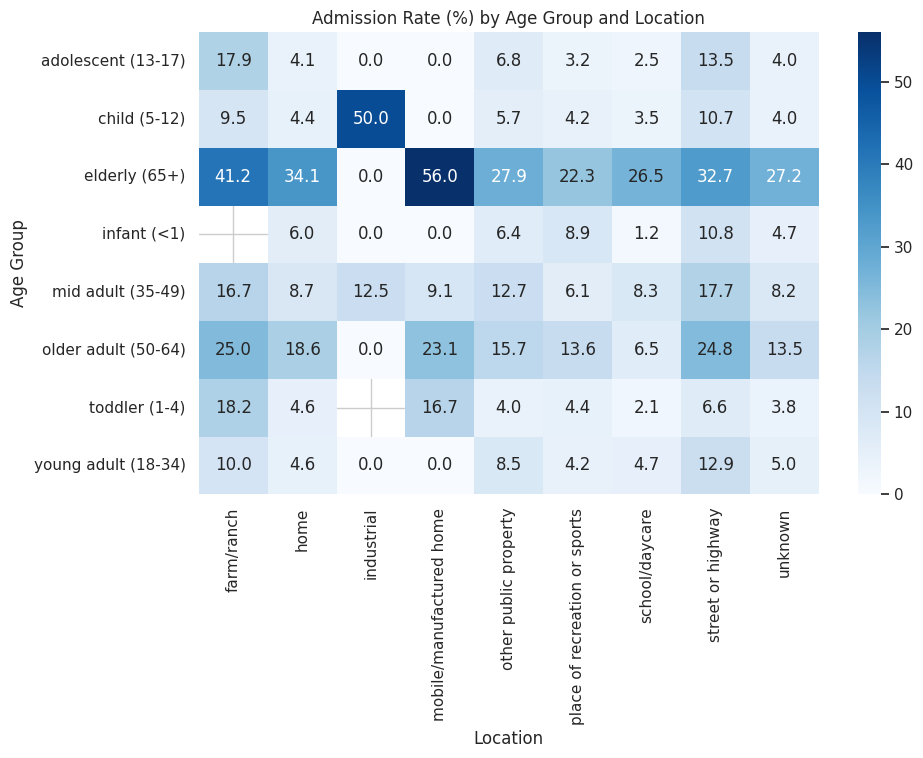

In [ ]:
age_location_heatmap = (
    age_location_table
    .pivot(index='age_group',
           columns='location',
           values='admission_rate')
)

plt.figure(figsize=(10,6))
sns.heatmap(
    age_location_heatmap,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Admission Rate (%) by Age Group and Location")
plt.ylabel("Age Group")
plt.xlabel("Location")
plt.show()



- Elderly (65+) have the highest admission rates in most locations. Especially in Mobile/manufactured homes ,Farm/ranch, Street/highway.

- Industrial injuries show high admission for children (50%),likely due to very small sample size.

## 3.5 Overall Exploratory Data Analysis

This exploratory analysis summarizes injury patterns and factors associated with hospital admission in the 2024 dataset.

Injuries were relatively stable across weekdays and showed a seasonal pattern, rising from April, peaking in September, and declining toward year-end. The age distribution was right-skewed, with most injuries affecting younger individuals but extending into older age groups.

Admission rates varied substantially across injury characteristics. Higher rates were observed in cases involving large body areas, submersion, fire-related events, and older adults (65+), while younger age groups and recreational settings showed consistently lower admission rates. Differences by sex, race, and ethnicity were comparatively small.

Multivariate descriptive analysis further indicated that fire involvement amplified admission risk across age groups, particularly among elderly patients. Elevated admission rates for elderly individuals were observed across several locations, including mobile/manufactured homes and street or highway settings. Some extreme subgroup rates likely reflect small sample sizes and should be interpreted cautiously.

Overall, injury severity—proxied by hospital admission—appears primarily driven by injury characteristics and age, with other demographic factors playing a smaller role. These findings guide variable selection for subsequent statistical modeling.